In [1]:
!pip install plotly

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/9.9 MB 4.2 MB/s eta 0:00:03
   -------- ------------------------------- 2.1/9.9 MB 4.7 MB/s eta 0:00:02
   ------------- -------------------------- 3.4/9.9 MB 5.0 MB/s eta 0:00:02
   ------------------- -------------------- 4.7/9.9 MB 5.4 MB/s eta 0:00:01
   ------------------------ --------------- 6.0/9.9 MB 5.7 MB/s eta 0:00:01
   ----------------------------- ---------- 7.3/9.9 MB 5.8 MB/s eta 0:00:01
   ---------------------------------- ----- 8.7/9.9 MB 5.9 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 5.9 MB/s  0:00:01



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
!python.exe -m pip install --upgrade pip

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ----------- ---------------------------- 0.5/1.8 MB 2.1 MB/s eta 0:00:01
   ----------------------- ---------------- 1.0/1.8 MB 2.4 MB/s eta 0:00:01
   ---------------------------------- ----- 1.6/1.8 MB 2.5 MB/s eta 0:00:01
   ---------------------------------------- 1.8/1.8 MB 2.5 MB/s  0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 26.0.1
    Uninstalling pip-26.0.1:
      Successfully uninstalled pip-26.0.1


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
openmim 0.3.9 requires opendatalab, which is not installed.


In [12]:
!pip install openpyxl

Defaulting to user installation because normal site-packages is not writeable

   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   ---------------------------------

# Install

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
path = r"C:\Users\Rudra\Desktop\kaggle\dsj\bank\voice_bot_leads_dummy_data_10k_with_pnl.xlsx"

df = pd.read_excel(path)

In [3]:
df

,lead_id,product_type,lead_source,call_attempted,call_connected,conversation_completed,interest_shown,qualification_status,language,call_duration_seconds,sms_triggered,sms_type,sms_delivered,sms_clicked,followup_completed,account_opened,loan_amount,revenue_pct,revenue_generated,bot_cost_rs
0,200000,Credit Card,Partner,Yes,No,No,No,Not Qualified,English,0,No,NaN,No,No,No,No,88503,0.056,0.0,0.00
1,200001,Personal Loan,Organic,Yes,Yes,Yes,Yes,Not Qualified,Hindi,122,Yes,Link,Yes,Yes,No,No,341094,0.047,0.0,5.70
2,200002,Personal Loan,Partner,Yes,Yes,Yes,Yes,Not Qualified,Hindi,100,Yes,Link,Yes,Yes,Yes,No,172478,0.055,0.0,5.00
3,200003,Personal Loan,Paid,Yes,Yes,No,No,Not Qualified,English,52,No,NaN,No,No,No,No,257104,0.062,0.0,2.60
4,200004,Business Loan,Partner,Yes,Yes,Yes,No,Not Qualified,Hindi,197,No,NaN,No,No,No,No,1442077,0.060,0.0,9.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,209995,Credit Card,Paid,Yes,Yes,Yes,No,Not Qualified,Hindi,194,No,NaN,No,No,No,No,143655,0.048,0.0,9.70
9996,209996,Business Loan,Partner,Yes,No,No,No,Not Qualified,Hindi,0,No,NaN,No,No,No,No,1100006,0.067,0.0,0.00
9997,209997,Personal Loan,Organic,Yes,No,No,No,Not Qualified,Regional,0,No,NaN,No,No,No,No,261783,0.055,0.0,0.00
9998,209998,Personal Loan,Paid,Yes,Yes,Yes,No,Not Qualified,Hindi,47,No,NaN,No,No,No,No,379326,0.054,0.0,2.35


In [4]:
df.columns

Index(['lead_id', 'product_type', 'lead_source', 'call_attempted',
       'call_connected', 'conversation_completed', 'interest_shown',
       'qualification_status', 'language', 'call_duration_seconds',
       'sms_triggered', 'sms_type', 'sms_delivered', 'sms_clicked',
       'followup_completed', 'account_opened', 'loan_amount', 'revenue_pct',
       'revenue_generated', 'bot_cost_rs'],
      dtype='object')

# Part 1

## • Identify largest drop-offs across voice and SMS.


In [5]:
# Convert Yes/No to 1/0 
cols = [
    'call_attempted','call_connected','conversation_completed',
    'interest_shown','sms_triggered','sms_delivered',
    'sms_clicked','followup_completed','account_opened'
]

for col in cols:
    df[col] = df[col].map({'Yes':1, 'No':0})

# Handle NA
df = df.fillna(0)

In [6]:
df.sample().T

,3019
lead_id,203019
product_type,Credit Card
lead_source,Paid
call_attempted,1
call_connected,1
conversation_completed,1
interest_shown,1
qualification_status,Qualified
language,English
call_duration_seconds,131


In [7]:
df['qualification_status'].value_counts()

qualification_status
Not Qualified       8657
Qualified            927
Non-Determinable     416
Name: count, dtype: int64

In [8]:
df['qualification_status'] = df['qualification_status'].map({'Not Qualified': 0, 'Qualified': 1, 'Non-Determinable': 0})

In [9]:
# Voice Funnel
print(f"Attempted: {df['call_attempted'].sum()}")
print(f"Connected: {df['call_connected'].sum()}")
print(f"Conversation: {df['conversation_completed'].sum()}")
print(f"Interested: {df['interest_shown'].sum()}")
print(f"Qualified: {df['qualification_status'].sum()}")

Attempted: 10000
Connected: 6509
Conversation: 4558
Interested: 2061
Qualified: 927


In [10]:
connection_calculation = np.round((df['call_connected'].sum() / df['call_attempted'].sum()) * 100, 2)
conversation_calculation = np.round((df['conversation_completed'].sum() / df['call_connected'].sum()) * 100, 2)
interest_calculation = np.round((df['interest_shown'].sum() / df['conversation_completed'].sum()) * 100, 2)
qualified_calculation = np.round((df['qualification_status'].sum() / df['interest_shown'].sum()) * 100, 2) 

In [11]:
print("Connection Rate:", connection_calculation)
print("Conversation Rate:", conversation_calculation)
print("Interest Rate:",interest_calculation)
print("Qualified Rate: ", qualified_calculation)


Connection Rate: 65.09
Conversation Rate: 70.03
Interest Rate: 45.22
Qualified Rate:  44.98


In [49]:
funnel_data = {
    "stage": [
        "call_attempted",
        "call_connected",
        "conversation",
        "interested",
        "qualified"
    ],
    "count": [
        df['call_attempted'].sum(),
        df['call_connected'].sum(),
        df['conversation_completed'].sum(),
        df['interest_shown'].sum(),
        df['qualification_status'].sum()
    ]
}

funnel_df = pd.DataFrame(funnel_data)

funnel_df['conversion_%'] = (funnel_df['count'] / funnel_df['count'].iloc[0]) * 100
funnel_df


,stage,count,conversion_%
0,call_attempted,10000,100.00
1,call_connected,6509,65.09
2,conversation,4558,45.58
3,interested,2061,20.61
4,qualified,927,9.27


In [50]:

fig = px.funnel(
    funnel_df,
    x='count',
    y='stage',
    text=funnel_df['conversion_%'].astype(str) + '%',
    title='Voice Funnel Analysis'
)

fig.show()

### sms

In [13]:
sms_funnel = {
    "Triggered": df['sms_triggered'].sum(),
    "Delivered": df['sms_delivered'].sum(),
    "Clicked": df['sms_clicked'].sum()
}

sms_funnel

{'Triggered': 2061, 'Delivered': 1920, 'Clicked': 604}

In [14]:
delivery_calculation = np.round(df['sms_delivered'].sum() / df['sms_triggered'].sum() * 100, 2)
click_calculation = np.round((df['sms_clicked'].sum() / df['sms_delivered'].sum()) * 100, 2)

print("Delivery Rate:", delivery_calculation)
print("Click Rate:", click_calculation)

Delivery Rate: 93.16
Click Rate: 31.46


In [51]:
sms_data = {
    "stage": [
        "sms_triggered",
        "sms_delivered",
        "sms_clicked"
    ],
    "count": [
        df['sms_triggered'].sum(),
        df['sms_delivered'].sum(),
        df['sms_clicked'].sum()
    ]
}

sms_df = pd.DataFrame(sms_data)
sms_df['conversion_%'] = ( sms_df['count'] / sms_df['count'].iloc[0] ) * 100
sms_df

,stage,count,conversion_%
0,sms_triggered,2061,100.000000
1,sms_delivered,1920,93.158661
2,sms_clicked,604,29.306162


In [52]:
print(sms_df)

fig = px.funnel(
    sms_df,
    x='count',
    y='stage',
    text=sms_df['conversion_%'].round(2).astype(str) + '%',
    title='SMS Funnel Analysis'
)
fig.show()

           stage  count  conversion_%
0  sms_triggered   2061    100.000000
1  sms_delivered   1920     93.158661
2    sms_clicked    604     29.306162


In [16]:
df.columns

Index(['lead_id', 'product_type', 'lead_source', 'call_attempted',
       'call_connected', 'conversation_completed', 'interest_shown',
       'qualification_status', 'language', 'call_duration_seconds',
       'sms_triggered', 'sms_type', 'sms_delivered', 'sms_clicked',
       'followup_completed', 'account_opened', 'loan_amount', 'revenue_pct',
       'revenue_generated', 'bot_cost_rs'],
      dtype='object')

In [17]:
df['sms_type']

0          0
1       Link
2       Link
3          0
4          0
        ... 
9995       0
9996       0
9997       0
9998       0
9999       0
Name: sms_type, Length: 10000, dtype: object

In [47]:
def plot_funnel_by(df, col):
    
    grouped = df.groupby('product_type').agg({
        'call_attempted':'sum',
        'call_connected':'sum',
        'conversation_completed':'sum',
        'interest_shown':'sum',
        #'qualification_status': 'sum',
        'sms_triggered': 'sum',
        'sms_delivered': 'sum',
        'sms_clicked': 'sum',
        'followup_completed': 'sum',
        'account_opened': 'sum'
    }).reset_index()

    # reshape
    funnel_long = grouped.melt(
        id_vars=col,
        var_name='Stage',
        value_name='Count'
    )

    fig = px.funnel(
        funnel_long,
        x='Count',
        y='Stage',
        color=col,
        title=f"Voice Funnel by {col}",
        width=1300,
        height=800
    )
    
    fig.show()

In [48]:
plot_funnel_by(df, col='product_type')

## Compare conversion and revenue by product, source, and language.

In [90]:
product_analysis = df.groupby('product_type').agg({
    'account_opened':'sum',
    'lead_id':'count',
    'revenue_generated':'sum',
    'bot_cost_rs': 'sum'
})

product_analysis['conversion_rate'] = np.round((product_analysis['account_opened'] / product_analysis['lead_id'])  * 1000, 2)

In [91]:
product_analysis = product_analysis.reset_index()
product_analysis

,product_type,account_opened,lead_id,revenue_generated,bot_cost_rs,conversion_rate
0,Business Loan,18,2015,870238.476,11373.02,8.93
1,Credit Card,50,4064,241453.340,22505.05,12.30
2,Personal Loan,37,3921,638708.933,21890.15,9.44


In [92]:
def plot_analysis(df, col):

    plt.bar(df[col], df["account_opened"])
    plt.title(f"Accounts Opened by {col}")
    plt.xlabel(f"{col}")
    plt.ylabel("Accounts Opened")
    plt.show()

    plt.pie(x=df["revenue_generated"], labels=df[col], autopct='%2.2f%%')
    plt.title("Revenue Generated")
    plt.show()

    plt.bar(df[col], df["conversion_rate"])
    plt.title(f"Conversion Rate by {col}")
    plt.xlabel(f"{col}")
    plt.ylabel("Conversion Rate")
    plt.show()
    
    plt.pie(x=df["bot_cost_rs"], labels=df[col], autopct='%2.2f%%')
    plt.title("Bot Cost")
    plt.show()

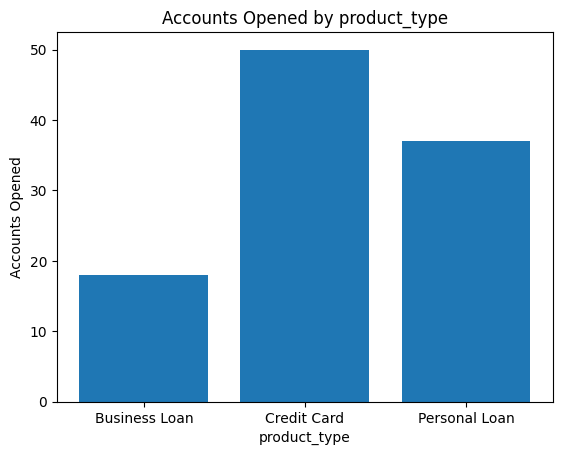

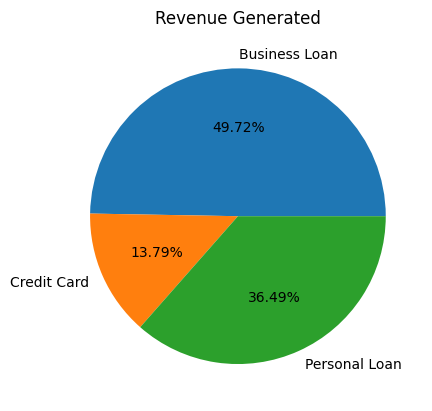

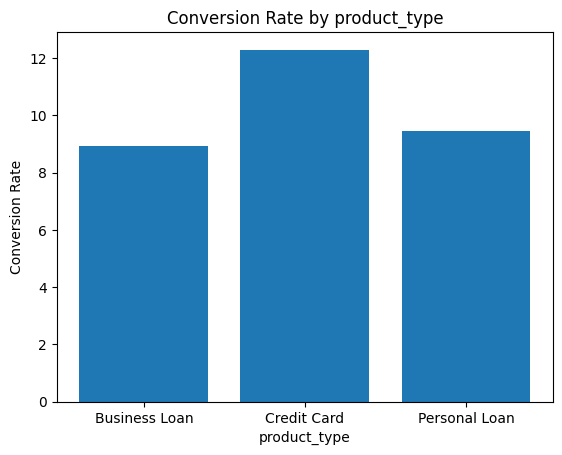

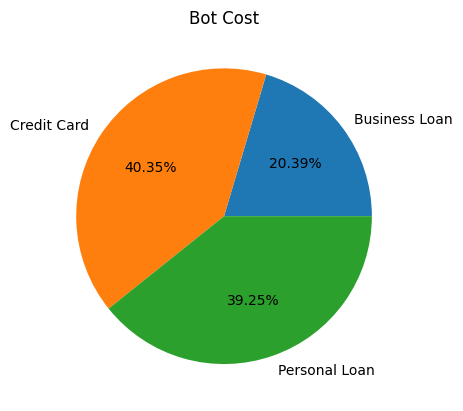

In [93]:
plot_analysis(df=product_analysis, col="product_type")

In [94]:
source_analysis = df.groupby('lead_source').agg({
    'account_opened':'sum',
    'lead_id':'count',
    'revenue_generated':'sum',
    'bot_cost_rs': 'sum'
})

source_analysis['conversion_rate'] = (source_analysis['account_opened'] / source_analysis['lead_id'])  * 1000

source_analysis

,account_opened,lead_id,revenue_generated,bot_cost_rs,conversion_rate
lead_source,,,,,
Organic,32,3505,644736.681,19808.80,9.129815
Paid,49,4487,709958.293,24732.49,10.920437
Partner,24,2008,395705.775,11226.93,11.952191


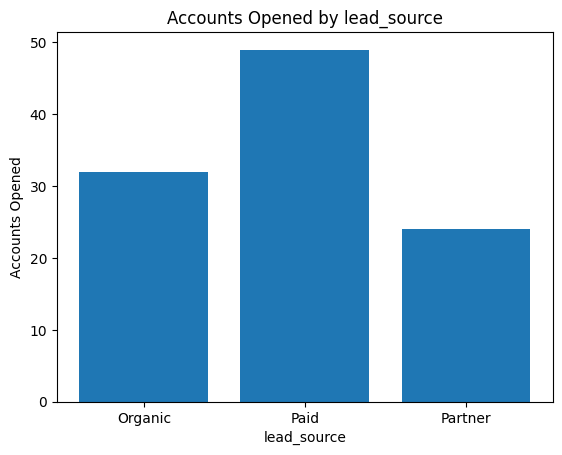

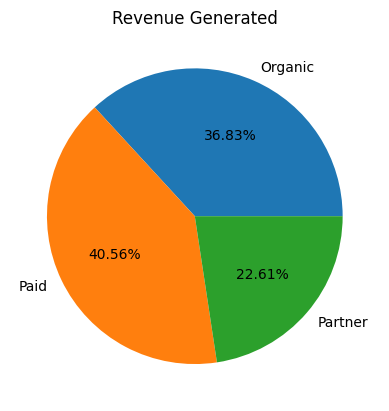

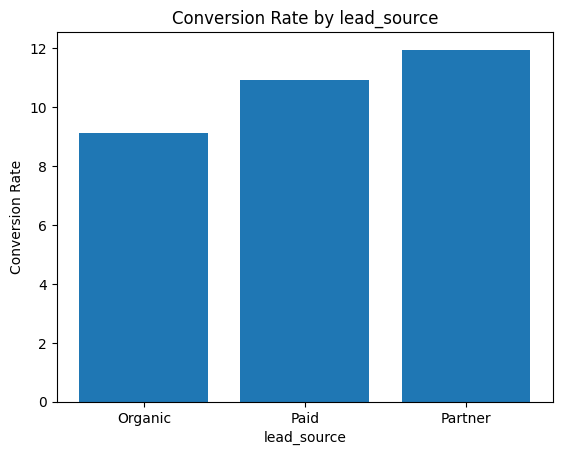

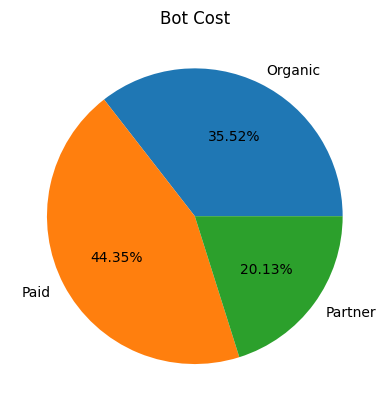

In [95]:
source_analysis = source_analysis.reset_index()

plot_analysis(df=source_analysis, col="lead_source")

In [73]:
df.columns

Index(['lead_id', 'product_type', 'lead_source', 'call_attempted',
       'call_connected', 'conversation_completed', 'interest_shown',
       'qualification_status', 'language', 'call_duration_seconds',
       'sms_triggered', 'sms_type', 'sms_delivered', 'sms_clicked',
       'followup_completed', 'account_opened', 'loan_amount', 'revenue_pct',
       'revenue_generated', 'bot_cost_rs', 'cost_per_conversion'],
      dtype='object')

In [96]:
lang_analysis = df.groupby('language').agg({
    'account_opened':'sum',
    'lead_id':'count',
    'revenue_generated':'sum',
    'bot_cost_rs': 'sum'
})

lang_analysis['conversion_rate'] = (lang_analysis['account_opened'] / lang_analysis['lead_id'])  * 1000

lang_analysis

,account_opened,lead_id,revenue_generated,bot_cost_rs,conversion_rate
language,,,,,
English,43,4024,668073.780,22871.70,10.685885
Hindi,45,4465,787460.857,24349.57,10.078387
Regional,17,1511,294866.112,8546.95,11.250827


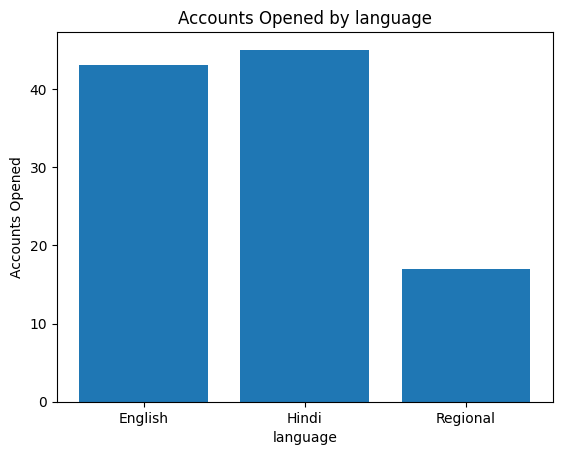

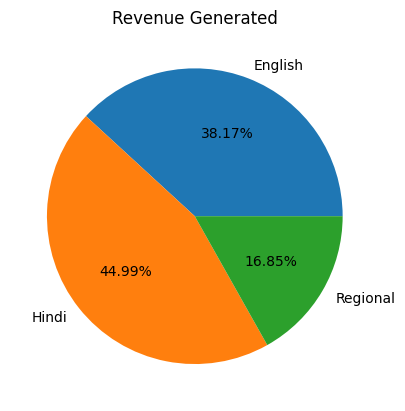

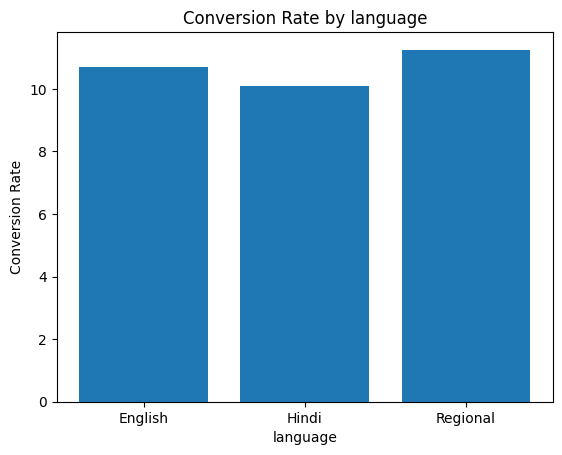

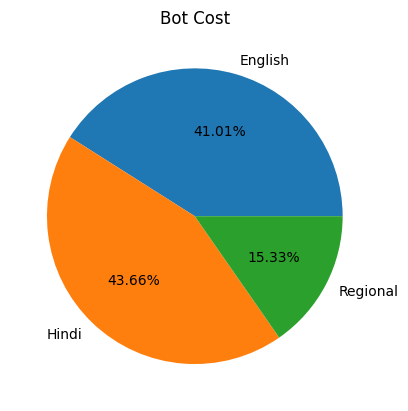

In [97]:
lang_analysis = lang_analysis.reset_index()

plot_analysis(df=lang_analysis, col="language")

# P2:  PnL Analysis

## Calculate total bot cost, total revenue, and net PnL.

In [40]:
total_revenue = df['revenue_generated'].sum()
total_cost = df['bot_cost_rs'].sum()

net_pnl = total_revenue - total_cost

print("Revenue:", total_revenue)
print("Cost:", total_cost)
print("Net PnL:", net_pnl)

Revenue: 1750400.749
Cost: 55768.22
Net PnL: 1694632.529


In [37]:
df['cost_per_conversion'] = df['bot_cost_rs'] / df['account_opened']

<Axes: xlabel='cost_per_conversion', ylabel='Count'>

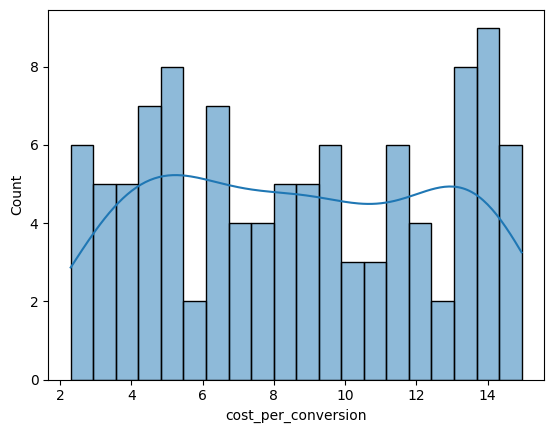

In [38]:
sns.histplot(df['cost_per_conversion'], kde=True, bins=20)

# Finding Format

Voice Funnel Insight

Largest drop-off occurs between call_attempted → call_connected

Product Insight

Personal Loan has higher conversion but lower profitability

Source Insight

Paid leads show high volume but low conversion → inefficient spend

PnL Insight

Overall campaign is profitable / loss-making by ₹X
Segment X is causing losses due to high bot cost but low conversion

### Language check 

- due to already credit is less so same for all language

In [69]:
hindi_df = df[df['language'] == 'Regional']

In [70]:
hindi_df.groupby('product_type')['revenue_generated'].count()

product_type
Business Loan    309
Credit Card      582
Personal Loan    620
Name: revenue_generated, dtype: int64

In [71]:
hindi_product = hindi_df.groupby('product_type').agg({
    'lead_id': 'count',
    'account_opened': 'sum',
    'revenue_generated': 'sum'
}).reset_index()

hindi_product['conversion_rate'] = hindi_product['account_opened'] / hindi_product['lead_id']
hindi_product.sort_values(by='revenue_generated', ascending=False)
hindi_product

,product_type,lead_id,account_opened,revenue_generated,conversion_rate
0,Business Loan,309,3,151957.110,0.009709
1,Credit Card,582,8,35599.345,0.013746
2,Personal Loan,620,6,107309.657,0.009677


In [72]:
import plotly.express as px

fig = px.bar(
    hindi_product,
    x='product_type',
    y='revenue_generated',
    text='revenue_generated',
    title='Revenue by Product (Hindi Users)'
)

fig.show()